In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [3]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [4]:
df = pd.read_csv(url)

# verify successful load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
826,2014,MITSUBISHI,OUTLANDER,SUV - SMALL,2.4,4,AV6,X,9.5,7.5,8.6,33,198
160,2014,CADILLAC,ATS AWD,COMPACT,2.0,4,AS6,Z,11.8,8.1,10.1,28,232
702,2014,MAZDA,MAZDA2,COMPACT,1.5,4,M5,X,8.0,6.7,7.4,38,170
162,2014,CADILLAC,CTS COUPE,MID-SIZE,3.6,6,AS6,X,13.2,8.7,11.2,25,258
681,2014,LINCOLN,MKT LIVERY AWD,SPECIAL PURPOSE VEHICLE,3.7,6,A6,X,14.0,9.9,12.2,23,281


In [5]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [6]:
# Drop categoricals and any unseless columns
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)

In [7]:
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [8]:
# Drop all but highest grouped corralated data columns (enginesize vs cylinders & FUELCONSUMPTION_CITY vs FUELCONSUMPTION_HWY vs FUELCONSUMPTION_HWY vs FUELCONSUMPTION_COMB_MPG)

df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)

df.head(9)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244
5,3.5,28,230
6,3.5,28,232
7,3.7,25,255
8,3.7,24,267


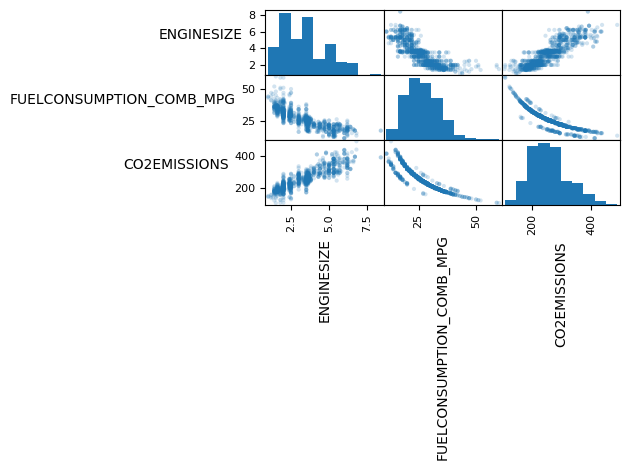

In [9]:
# plot columns against each other visualally to help select predictive features

axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

In [10]:
# Extract the required columns and convert the resulting dataframes to NumPy arrays.

X = df.iloc[:,[0,1]].to_numpy()
# x holding enginesize and fuel consumption variables  
y = df.iloc[:,[2]].to_numpy()
# y holding emission variable

In [11]:
# Preprocess selected features

# You should standardize your input features so the model doesn't inadvertently favor any feature due to its magnitude.
# The typical way to do this is to subtract the mean and divide by the standard deviation.

from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

pd.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [12]:
# Seperate data into train and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)

Coefficients:  [[ 25.27339614 -37.4381472 ]]
Intercept:  [256.29072488]


In [13]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)

Coefficients:  [[17.8581369  -5.01502179]]
Intercept:  [329.1363967]


[ 0.95652341  0.10860554  0.17926536 -0.24469358 -0.9512918  -0.24469358
  0.17926536  0.46190465  1.16850288  0.17926536  0.17926536  2.36971987
 -0.10337393  0.10860554  0.17926536  0.10860554 -1.23393109  0.17926536
 -1.23393109  1.38048235  1.16850288 -1.09261145 -0.10337393  0.24992518
 -0.24469358 -1.09261145 -0.9512918  -1.23393109  1.52180199 -0.10337393
  1.45114217 -0.66865251 -1.09261145  1.16850288 -0.24469358  0.95652341
  0.46190465  1.38048235 -0.9512918  -0.59799269 -1.23393109 -1.23393109
 -1.37525074 -0.59799269  0.46190465 -1.23393109 -0.24469358 -0.24469358
 -0.9512918   1.30982252  2.01642075  0.17926536 -0.9512918   0.24992518
 -0.24469358  1.38048235  1.38048235  1.66312164 -0.9512918   0.67388412
  0.46190465  0.67388412  0.74454394  0.17926536 -1.23393109  0.03794572
 -1.37525074  1.02718323 -0.24469358  0.24992518  1.16850288 -0.9512918
  0.10860554 -0.9512918  -0.9512918   0.17926536  1.38048235  2.01642075
  2.01642075  0.10860554 -0.66865251 -1.09261145 -0.

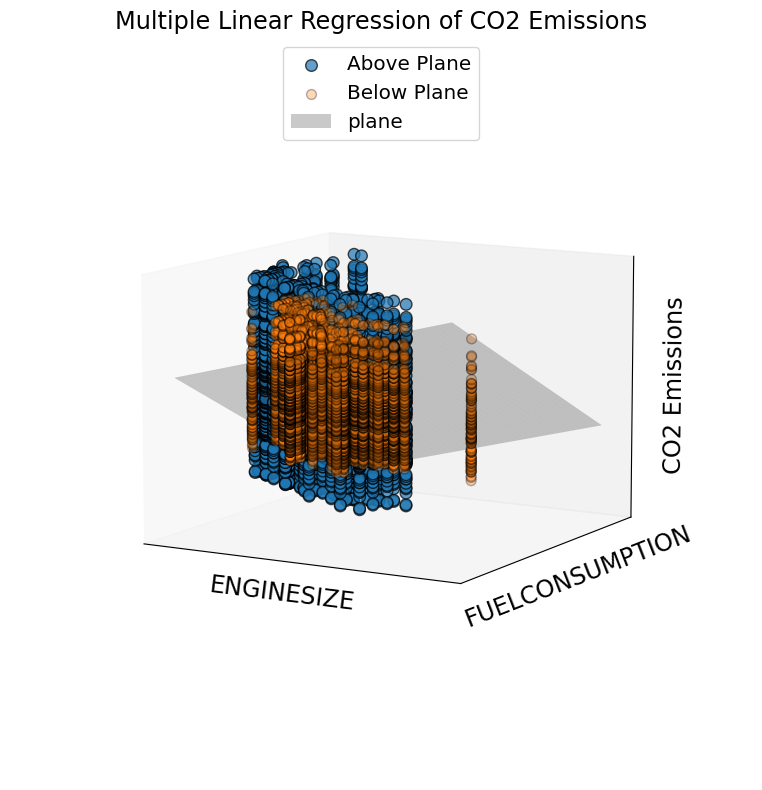

In [14]:
#from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

print(X_test[:, 0])

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],  label="Above Plane",s=70,alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],  label="Below Plane",s=50,alpha=.3,ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plane')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()

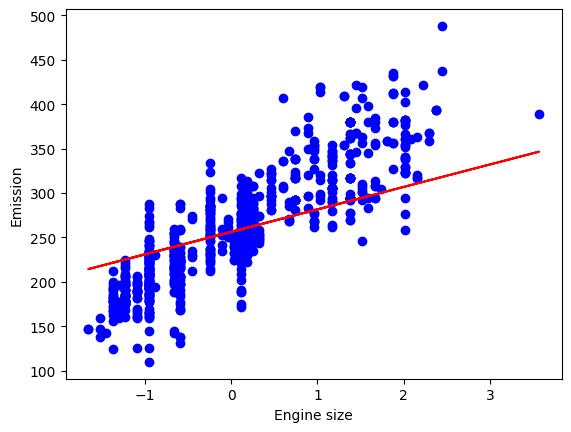

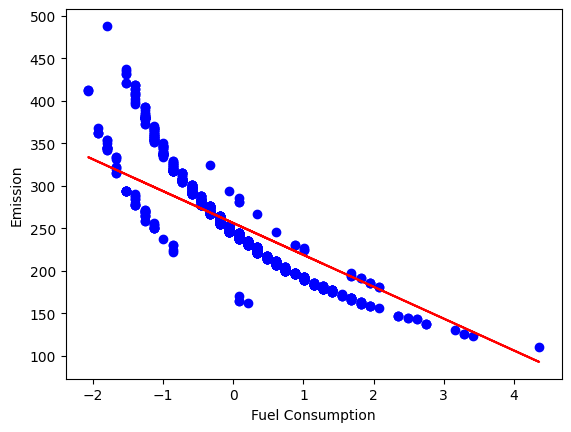

In [15]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("Fuel Consumption")
plt.ylabel("Emission")
plt.show()

In [16]:
# Determine and print the parameters for the best-fit linear regression line for CO2 emission with respect to engine size.

X_train_1 = X_train[:,0]

regressor_1 = linear_model.LinearRegression()
regressor_1.fit(X_train_1.reshape(-1, 1), y_train)
coef_1 =  regressor_1.coef_
intercept_1 = regressor_1.intercept_

print ('Coefficients: ',coef_1[0])
print ('Intercept: ',intercept_1)

Coefficients:  [55.18408797]
Intercept:  [256.77183014]


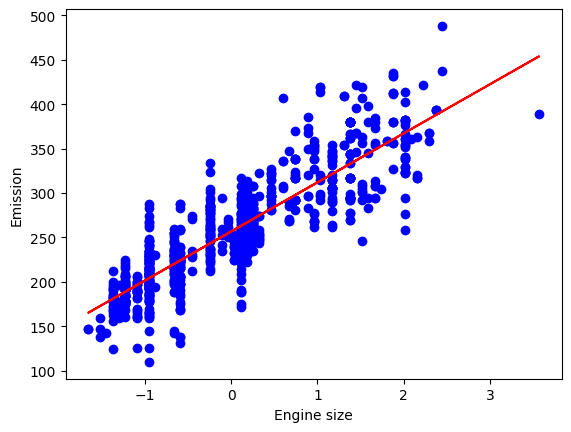

In [17]:
# Produce a scatterplot of CO2 emission against ENGINESIZE and include the best-fit regression line to the training data.

plt.scatter(X_train_1, y_train,  color='blue')
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

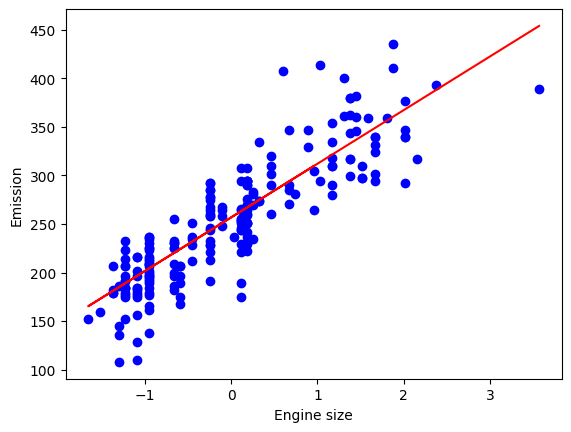

In [18]:
# Generate the same scatterplot and best-fit regression line, but now base the result on the test data set. 
# Consider how the test result compares to the training result.

X_test_1 = X_test[:,0]
plt.scatter(X_test_1, y_test,  color='blue')
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

Coefficients:  [-58.51827989]
Intercept:  [256.09392179]


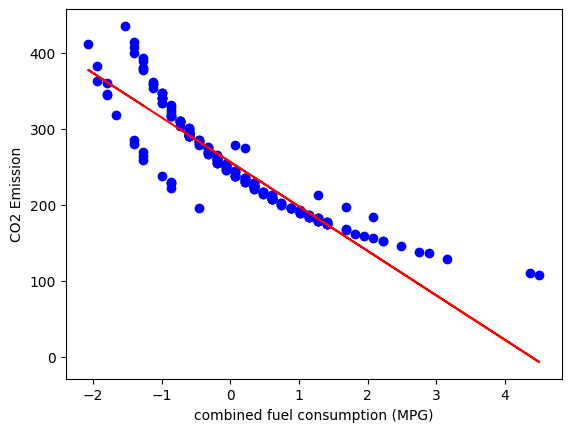

In [19]:
# Repeat the same modeling but use FUELCONSUMPTION_COMB_MPG as the independent variable instead.
# Display the model coefficients including the intercept.

X_train_2 = X_train[:,1]

regressor_2 = linear_model.LinearRegression()
regressor_2.fit(X_train_2.reshape(-1, 1), y_train)
coef_2 =  regressor_2.coef_
intercept_2 = regressor_2.intercept_

print ('Coefficients: ',coef_2[0])
print ('Intercept: ',intercept_2)

X_test_2 = X_test[:,1]
plt.scatter(X_test_2, y_test,  color='blue')
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2[0], '-r')
plt.xlabel("combined fuel consumption (MPG)")
plt.ylabel("CO2 Emission")
plt.show()